In [1]:
import pandas as pd
df = pd.read_csv("../data/raw/hotel_bookings.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [3]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [4]:
df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-'+
    df['arrival_date_month'] + '-'+
    df['arrival_date_day_of_month'].astype(str)
)

df['arrival_date']

0        2015-07-01
1        2015-07-01
2        2015-07-01
3        2015-07-01
4        2015-07-01
            ...    
119385   2017-08-30
119386   2017-08-31
119387   2017-08-31
119388   2017-08-31
119389   2017-08-29
Name: arrival_date, Length: 119390, dtype: datetime64[ns]

In [5]:
daily_demand =(
    df.groupby('arrival_date')
    .size()
    .reset_index(name='bookings')
)
daily_demand = daily_demand.sort_values('arrival_date')

In [6]:
daily_demand

,arrival_date,bookings
0,2015-07-01,122
1,2015-07-02,93
2,2015-07-03,56
3,2015-07-04,88
4,2015-07-05,53
...,...,...
788,2017-08-27,174
789,2017-08-28,211
790,2017-08-29,125
791,2017-08-30,89


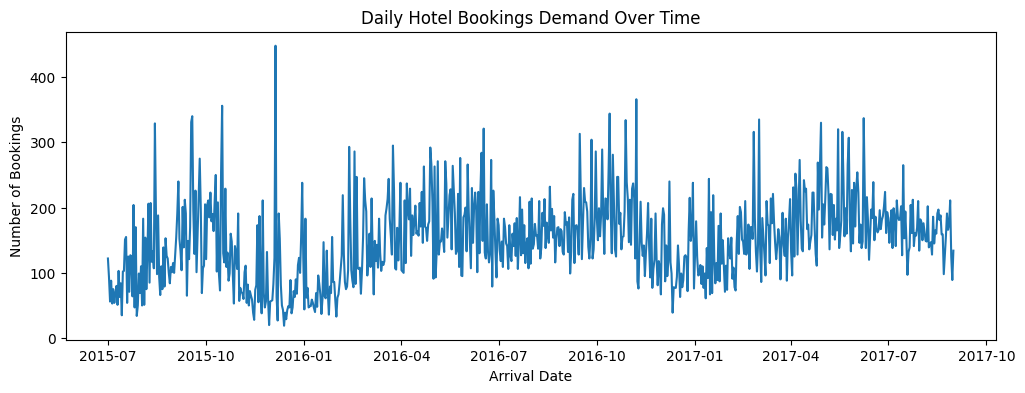

In [7]:
# plot demand over time
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.plot(daily_demand['arrival_date'], daily_demand['bookings'])
plt.title('Daily Hotel Bookings Demand Over Time')
plt.xlabel('Arrival Date')
plt.ylabel('Number of Bookings')
plt.show()

In [8]:
daily_demand['month'] = daily_demand['arrival_date'].dt.month
daily_demand['month'].head()


0    7
1    7
2    7
3    7
4    7
Name: month, dtype: int32

In [9]:
print(daily_demand['month'].to_string())


0       7
1       7
2       7
3       7
4       7
5       7
6       7
7       7
8       7
9       7
10      7
11      7
12      7
13      7
14      7
15      7
16      7
17      7
18      7
19      7
20      7
21      7
22      7
23      7
24      7
25      7
26      7
27      7
28      7
29      7
30      7
31      8
32      8
33      8
34      8
35      8
36      8
37      8
38      8
39      8
40      8
41      8
42      8
43      8
44      8
45      8
46      8
47      8
48      8
49      8
50      8
51      8
52      8
53      8
54      8
55      8
56      8
57      8
58      8
59      8
60      8
61      8
62      9
63      9
64      9
65      9
66      9
67      9
68      9
69      9
70      9
71      9
72      9
73      9
74      9
75      9
76      9
77      9
78      9
79      9
80      9
81      9
82      9
83      9
84      9
85      9
86      9
87      9
88      9
89      9
90      9
91      9
92     10
93     10
94     10
95     10
96     10
97     10
98     10
99     10


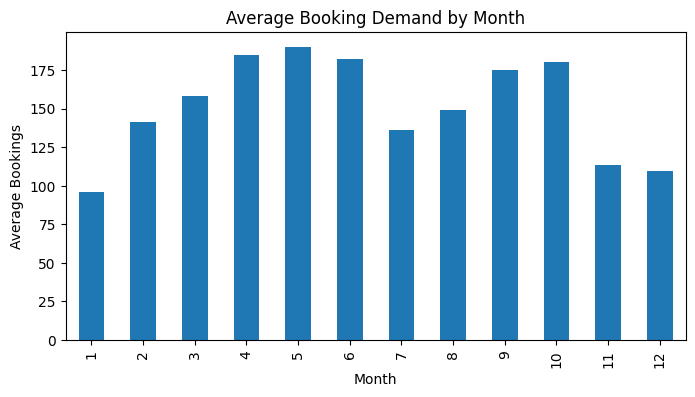

In [10]:
# average demand per month
monthly_avg = daily_demand.groupby('month')['bookings'].mean()

plt.figure(figsize=(8,4))
monthly_avg.plot(kind='bar')
plt.title("Average Booking Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Bookings")
plt.show()



In [11]:
# weekend feature
daily_demand['day_of_week'] = daily_demand['arrival_date'].dt.dayofweek
daily_demand['is_weekend'] = daily_demand['day_of_week'].isin([5,6]).astype(int)

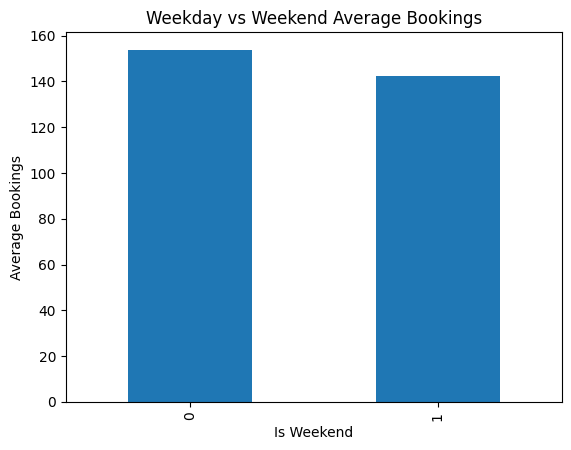

In [12]:
weekend_avg  = daily_demand.groupby('is_weekend')['bookings'].mean()
weekend_avg.plot(kind='bar')
plt.title("Weekday vs Weekend Average Bookings")
plt.xlabel("Is Weekend")
plt.ylabel("Average Bookings")
plt.show()

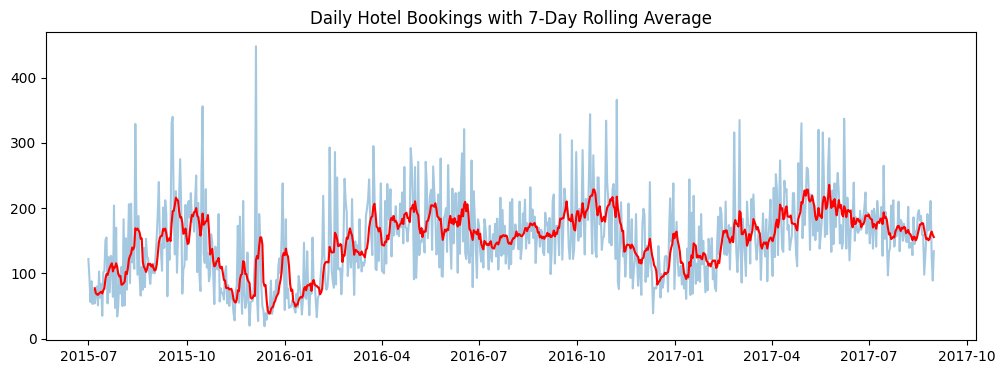

In [13]:
daily_demand['rolling_7'] = daily_demand['bookings'].rolling(window=7).mean()

plt.figure(figsize=(12,4))
plt.plot(daily_demand['arrival_date'], daily_demand['bookings'] , alpha=0.4)
plt.plot(daily_demand['arrival_date'], daily_demand['rolling_7'], color='red')
plt.title('Daily Hotel Bookings with 7-Day Rolling Average')
plt.show()